In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eyesa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\eyesa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\eyesa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

## EDA

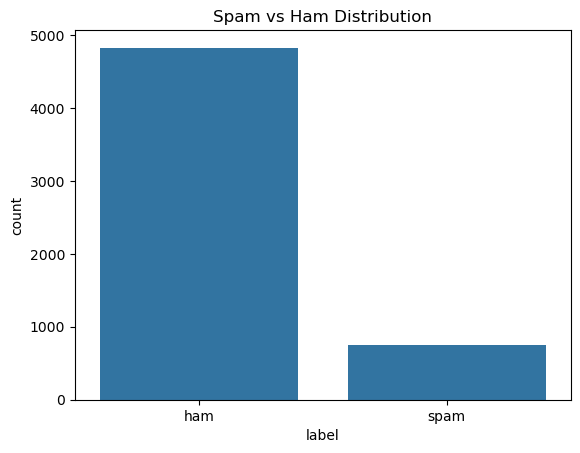

In [7]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [8]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

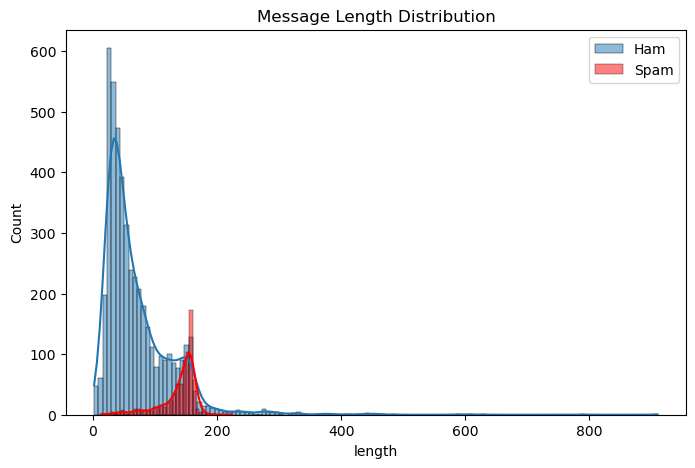

In [9]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df[df['label']==0]['length'], label='Ham', kde=True)
sns.histplot(df[df['label']==1]['length'], label='Spam', color='red', kde=True)
plt.legend()
plt.title("Message Length Distribution")
plt.show()

## Text Preprocessing

In [10]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

df['cleaned'] = df['message'].apply(preprocess)

## Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
X = df['cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Bag of Words

In [13]:
bow = CountVectorizer(max_features=3000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [14]:
model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)

MultinomialNB()

In [15]:
y_pred_bow = model_bow.predict(X_test_bow)

## Evaluation

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

Accuracy: 0.9806173725771715
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1202
           1       0.94      0.92      0.93       191

    accuracy                           0.98      1393
   macro avg       0.96      0.96      0.96      1393
weighted avg       0.98      0.98      0.98      1393



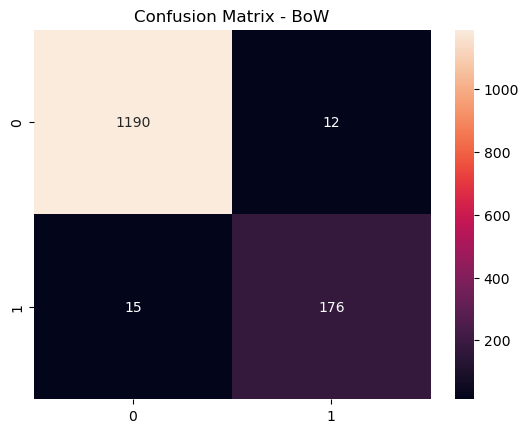

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred_bow), annot=True, fmt='d')
plt.title("Confusion Matrix - BoW")
plt.show()

## TF - IDF 

In [18]:
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [19]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

In [20]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

Accuracy: 0.9676956209619526
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1202
           1       0.99      0.77      0.87       191

    accuracy                           0.97      1393
   macro avg       0.98      0.89      0.92      1393
weighted avg       0.97      0.97      0.97      1393



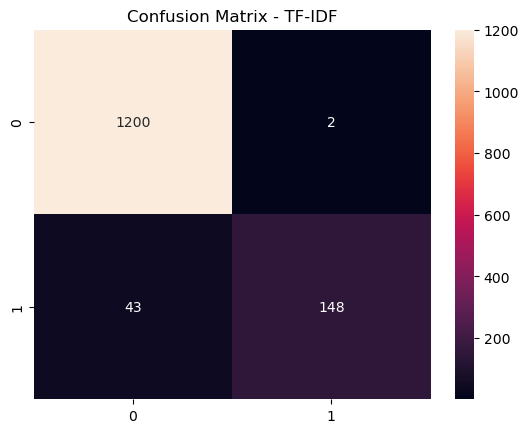

In [22]:
sns.heatmap(confusion_matrix(y_test, y_pred_tfidf), annot=True, fmt='d')
plt.title("Confusion Matrix - TF-IDF")
plt.show()

In [23]:
print("BoW Accuracy:", accuracy_score(y_test, y_pred_bow))
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))

BoW Accuracy: 0.9806173725771715
TF-IDF Accuracy: 0.9676956209619526


In [24]:
def predict_spam(text):
    text = preprocess(text)
    vec = tfidf.transform([text])
    result = model_tfidf.predict(vec)
    
    return "Spam" if result[0] == 1 else "Not Spam"

print(predict_spam("Congratulations! You won a free ticket"))
print(predict_spam("You have been assigned as a manager now"))
print(predict_spam("You have exhausted your complete data for today"))
print(predict_spam("You have a missed call from xyz 20 mins ago"))

Spam
Not Spam
Not Spam
Not Spam


In [25]:
import pickle

pickle.dump(model_tfidf, open("spam_model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))